In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

# 1. Chargement des données
df = pd.read_csv('export_IA.csv')

# 2. Sélection des variables d'entrée (Features) et de la cible (Target)
colonnes_entree = ['implantation_station', 'nbre_pdc', 'consolidated_latitude', 'consolidated_longitude']
colonne_cible = 'puissance_nominale'

df_model = df[colonnes_entree + [colonne_cible]].copy()

# 3. L'astuce pour forcer la CLASSIFICATION
# On convertit les puissances (nombres) en texte (chaînes de caractères). 
# Ainsi, l'IA ne verra plus le nombre "50.0", mais l'étiquette/la boîte "50.0".
df_model[colonne_cible] = df_model[colonne_cible].astype(str)

# 4. Encodage des données textuelles
# L'IA ne comprend pas le mot "Voirie" ou "Parking". On transforme ces mots en codes numériques (0, 1, 2...).
encodeur_implantation = LabelEncoder()
df_model['implantation_station'] = encodeur_implantation.fit_transform(df_model['implantation_station'])

# Sauvegarde de l'encodeur (Obligatoire pour ton script final à la fin du projet)
with open('encodeur_implantation.pkl', 'wb') as f:
    pickle.dump(encodeur_implantation, f)

# 5. Le découpage 80% (Entraînement) / 20% (Test)
X = df_model[colonnes_entree] # Les variables d'entrée
y = df_model[colonne_cible]   # Ce qu'on cherche à prédire

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Données prêtes ! L'IA va s'entraîner sur {X_train.shape[0]} bornes.")
print(f"Elle sera évaluée sur un examen aveugle de {X_test.shape[0]} bornes.")

Données prêtes ! L'IA va s'entraîner sur 3826 bornes.
Elle sera évaluée sur un examen aveugle de 957 bornes.


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pickle

print("Lancement de l'entraînement et de l'optimisation (GridSearchCV)... Cela peut prendre un peu de temps.")

# 1. Définition du modèle de base
modele_rf = RandomForestClassifier(random_state=42)

# 2. La "Grille" de réglages à tester
# On demande à GridSearchCV de tester des forêts de 50 ou 100 arbres, avec différentes profondeurs.
parametres_a_tester = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 3. L'automatisation des tests (GridSearchCV)
# cv=3 signifie qu'il va revérifier ses résultats 3 fois pour être sûr
recherche_optimale = GridSearchCV(estimator=modele_rf, param_grid=parametres_a_tester, cv=3, n_jobs=-1, verbose=1)

# 4. L'entraînement réel (L'IA apprend sur les 3826 bornes)
recherche_optimale.fit(X_train, y_train)

# 5. Extraction du modèle Champion
meilleur_modele = recherche_optimale.best_estimator_

# 6. Sauvegarde du modèle sur ton disque dur (Pour le script final du livrable)
with open('modele_puissance.pkl', 'wb') as f:
    pickle.dump(meilleur_modele, f)

print("\n--- Entraînement terminé ! ---")
print("Les meilleurs réglages trouvés par l'IA sont :", recherche_optimale.best_params_)
print("Le modèle 'Champion' a été sauvegardé sous le nom 'modele_puissance.pkl'.")

Lancement de l'entraînement et de l'optimisation (GridSearchCV)... Cela peut prendre un peu de temps.
Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(



--- Entraînement terminé ! ---
Les meilleurs réglages trouvés par l'IA sont : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Le modèle 'Champion' a été sauvegardé sous le nom 'modele_puissance.pkl'.


In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


✅ Note globale (Accuracy) : 51.93 %

--- Détail par catégorie (Classification Report) ---
              precision    recall  f1-score   support

       100.0       0.08      0.05      0.06        21
       104.0       0.00      0.00      0.00         1
       108.0       0.00      0.00      0.00         1
       120.0       0.62      0.89      0.73       148
       150.0       0.61      0.74      0.67       234
       160.0       0.20      0.20      0.20         5
       175.0       0.07      0.20      0.10        10
       180.0       0.52      0.27      0.35        52
       200.0       0.60      0.21      0.32        14
       210.0       0.00      0.00      0.00         1
       22.08       0.16      0.16      0.16        73
       224.0       0.00      0.00      0.00         1
       225.0       0.67      1.00      0.80         4
        24.0       0.84      0.81      0.82        58
       240.0       1.00      0.40      0.57         5
        25.0       0.83      0.68      0.75  

c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

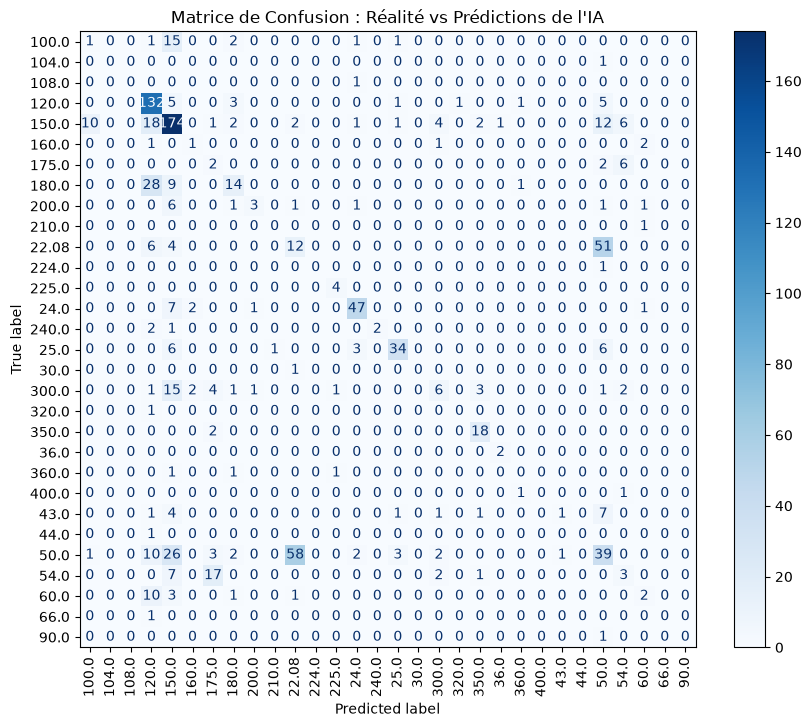

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. L'IA passe l'examen aveugle
predictions = meilleur_modele.predict(X_test)

# 2. La note globale (Accuracy)
precision_globale = accuracy_score(y_test, predictions)
print(f"✅ Note globale (Accuracy) : {precision_globale * 100:.2f} %\n")

# 3. Le bulletin détaillé (Rappel, Précision)
print("--- Détail par catégorie (Classification Report) ---")
print(classification_report(y_test, predictions))

# 4. Affichage visuel de la Matrice de Confusion
print("\n--- Génération de la Matrice de Confusion ---")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title("Matrice de Confusion : Réalité vs Prédictions de l'IA")
plt.show()

In [9]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Entraînement express en cours...


C:\Users\PC\AppData\Local\Temp\ipykernel_28244\3730879458.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')


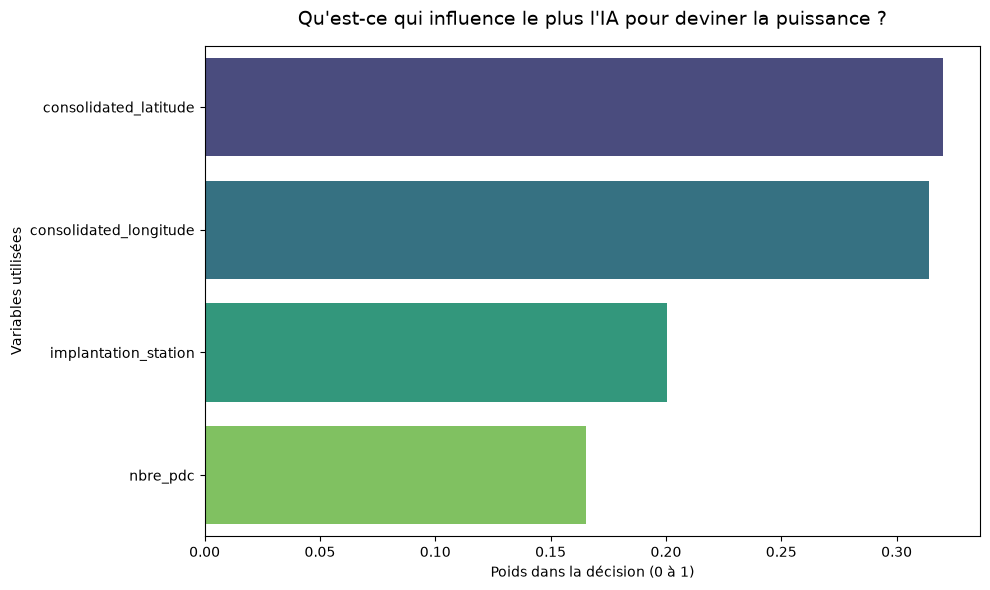

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Chargement rapide des données
df = pd.read_csv('export_IA.csv')
colonnes_entree = ['implantation_station', 'nbre_pdc', 'consolidated_latitude', 'consolidated_longitude']

# 2. Préparation des données
X = df[colonnes_entree].copy()
y = df['puissance_nominale'].astype(str)

encodeur = LabelEncoder()
X['implantation_station'] = encodeur.fit_transform(X['implantation_station'])

# 3. Entraînement express (juste pour le graphique)
print("Entraînement express en cours...")
modele_rapide = RandomForestClassifier(n_estimators=50, random_state=42)
modele_rapide.fit(X, y)

# 4. Extraction et Tri de l'importance
importances = modele_rapide.feature_importances_
df_importance = pd.DataFrame({'Variable': colonnes_entree, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 5. Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')

plt.title("Qu'est-ce qui influence le plus l'IA pour deviner la puissance ?", fontsize=14, pad=15)
plt.xlabel("Poids dans la décision (0 à 1)")
plt.ylabel("Variables utilisées")
plt.tight_layout()
plt.show()

In [11]:
import pickle
# ... (ton code d'entraînement) ...
with open('modele_puissance.pkl', 'wb') as f:
    pickle.dump(meilleur_modele, f)